In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

df = pd.read_excel(r'C:\Users\User\Downloads\AMR_merged_all_samples_ordered.xlsx')


In [114]:
print("Raw Data Preview:")
display(df.head())

Raw Data Preview:


,Sample_ID,Origin,Bacteria,Antibiotic1,+Ceftazidime/Avibactam,Amikacin,Amoxicillin/Clavulanic Acid,Cefalexin,Cefalotin,Cefovecin,...,Gentamicin,Imipenem,Marbofloxacin,Neomycin,Nitrofurantoin,Pradofloxacin,Tetracycline,Trimethoprim/ Sulfamethoxazole,PC1,PC2
0,ASTMMSAMHMR3C2-1,APMC HALLWAY,Staphylococcus saprophyticus,R,NaN,NaN,NaN,NaN,NaN,NaN,...,S,NaN,NaN,NaN,S,NaN,S,R,-0.914937,-0.392627
1,ASTEMSAMHDR1C2-1,APMC HALLWAY,Staphylococcus haemolyticus,R,NaN,NaN,NaN,NaN,NaN,NaN,...,S,NaN,NaN,NaN,S,NaN,S,R,-0.914937,-0.392627
2,ASTEEFMHDR1C2-1,APMC HALLWAY,Enterococcus faecium,R,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,S,NaN,S,NaN,-0.990216,-0.549635
3,ASTEMSAMHCR2C1-1,APMC HALLWAY,Enterococcus faecium,R,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,S,NaN,S,NaN,-0.990216,-0.549635
4,ASTMMSAMHCR2C3-1,APMC HALLWAY,Enterococcus faecalis,R,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,S,NaN,S,NaN,-0.990216,-0.549635


In [56]:
df = df.drop_duplicates().dropna(how="all")

In [57]:
print(df)

              Sample_ID               Origin                         Bacteria  \
0      ASTMMSAMHMR3C2-1         APMC HALLWAY     Staphylococcus saprophyticus   
1      ASTEMSAMHDR1C2-1         APMC HALLWAY      Staphylococcus haemolyticus   
2       ASTEEFMHDR1C2-1         APMC HALLWAY             Enterococcus faecium   
3      ASTEMSAMHCR2C1-1         APMC HALLWAY             Enterococcus faecium   
4      ASTMMSAMHCR2C3-1         APMC HALLWAY            Enterococcus faecalis   
..                  ...                  ...                              ...   
273   ASTMCETOSWBR1C2-1  ORMOC SURGICAL WARD  Acinetobacter baumannii complex   
274   ASTMMACOSWBR1C3-1  ORMOC SURGICAL WARD  Acinetobacter baumannii complex   
275  ASTMMACOSWFLR5C2-1  ORMOC SURGICAL WARD  Acinetobacter baumannii complex   
276  ASTMMACOSWFLR5C3-1  ORMOC SURGICAL WARD  Acinetobacter baumannii complex   
277   ASTMMACOSWWR4C2-1  ORMOC SURGICAL WARD  Acinetobacter baumannii complex   

    Antibiotic1 +Ceftazidim

In [58]:
mapping = {
    "Resistant": 1,
    "Susceptible": 0,
    "Intermediate": 0.5,
    "R": 1,
    "S": 0,
    "I": 0.5
}
df = df.replace(mapping)
display(df)

C:\Users\User\AppData\Local\Temp\ipykernel_31352\575497160.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(mapping)


,Sample_ID,Origin,Bacteria,Antibiotic1,+Ceftazidime/Avibactam,Amikacin,Amoxicillin/Clavulanic Acid,Cefalexin,Cefalotin,Cefovecin,...,Doxycycline,Enrofloxacin,Gentamicin,Imipenem,Marbofloxacin,Neomycin,Nitrofurantoin,Pradofloxacin,Tetracycline,Trimethoprim/ Sulfamethoxazole
0,ASTMMSAMHMR3C2-1,APMC HALLWAY,Staphylococcus saprophyticus,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,0.0,1.0
1,ASTEMSAMHDR1C2-1,APMC HALLWAY,Staphylococcus haemolyticus,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,0.0,1.0
2,ASTEEFMHDR1C2-1,APMC HALLWAY,Enterococcus faecium,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASTEMSAMHCR2C1-1,APMC HALLWAY,Enterococcus faecium,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASTMMSAMHCR2C3-1,APMC HALLWAY,Enterococcus faecalis,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,ASTMCETOSWBR1C2-1,ORMOC SURGICAL WARD,Acinetobacter baumannii complex,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0
274,ASTMMACOSWBR1C3-1,ORMOC SURGICAL WARD,Acinetobacter baumannii complex,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0
275,ASTMMACOSWFLR5C2-1,ORMOC SURGICAL WARD,Acinetobacter baumannii complex,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0
276,ASTMMACOSWFLR5C3-1,ORMOC SURGICAL WARD,Acinetobacter baumannii complex,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0


In [59]:
df.isnull().sum()

Sample_ID                          0
Origin                             0
Bacteria                           0
Antibiotic1                       81
+Ceftazidime/Avibactam            98
Amikacin                          57
Amoxicillin/Clavulanic Acid       79
Cefalexin                         79
Cefalotin                         79
Cefovecin                         29
Cefpodoxime                       79
Ceftiofur                         29
Chloramphenicol                   79
Doxycycline                       51
Enrofloxacin                      29
Gentamicin                        15
Imipenem                          29
Marbofloxacin                     29
Neomycin                          79
Nitrofurantoin                    50
Pradofloxacin                     79
Tetracycline                      22
Trimethoprim/ Sulfamethoxazole    66
dtype: int64

Visualization of Distributions

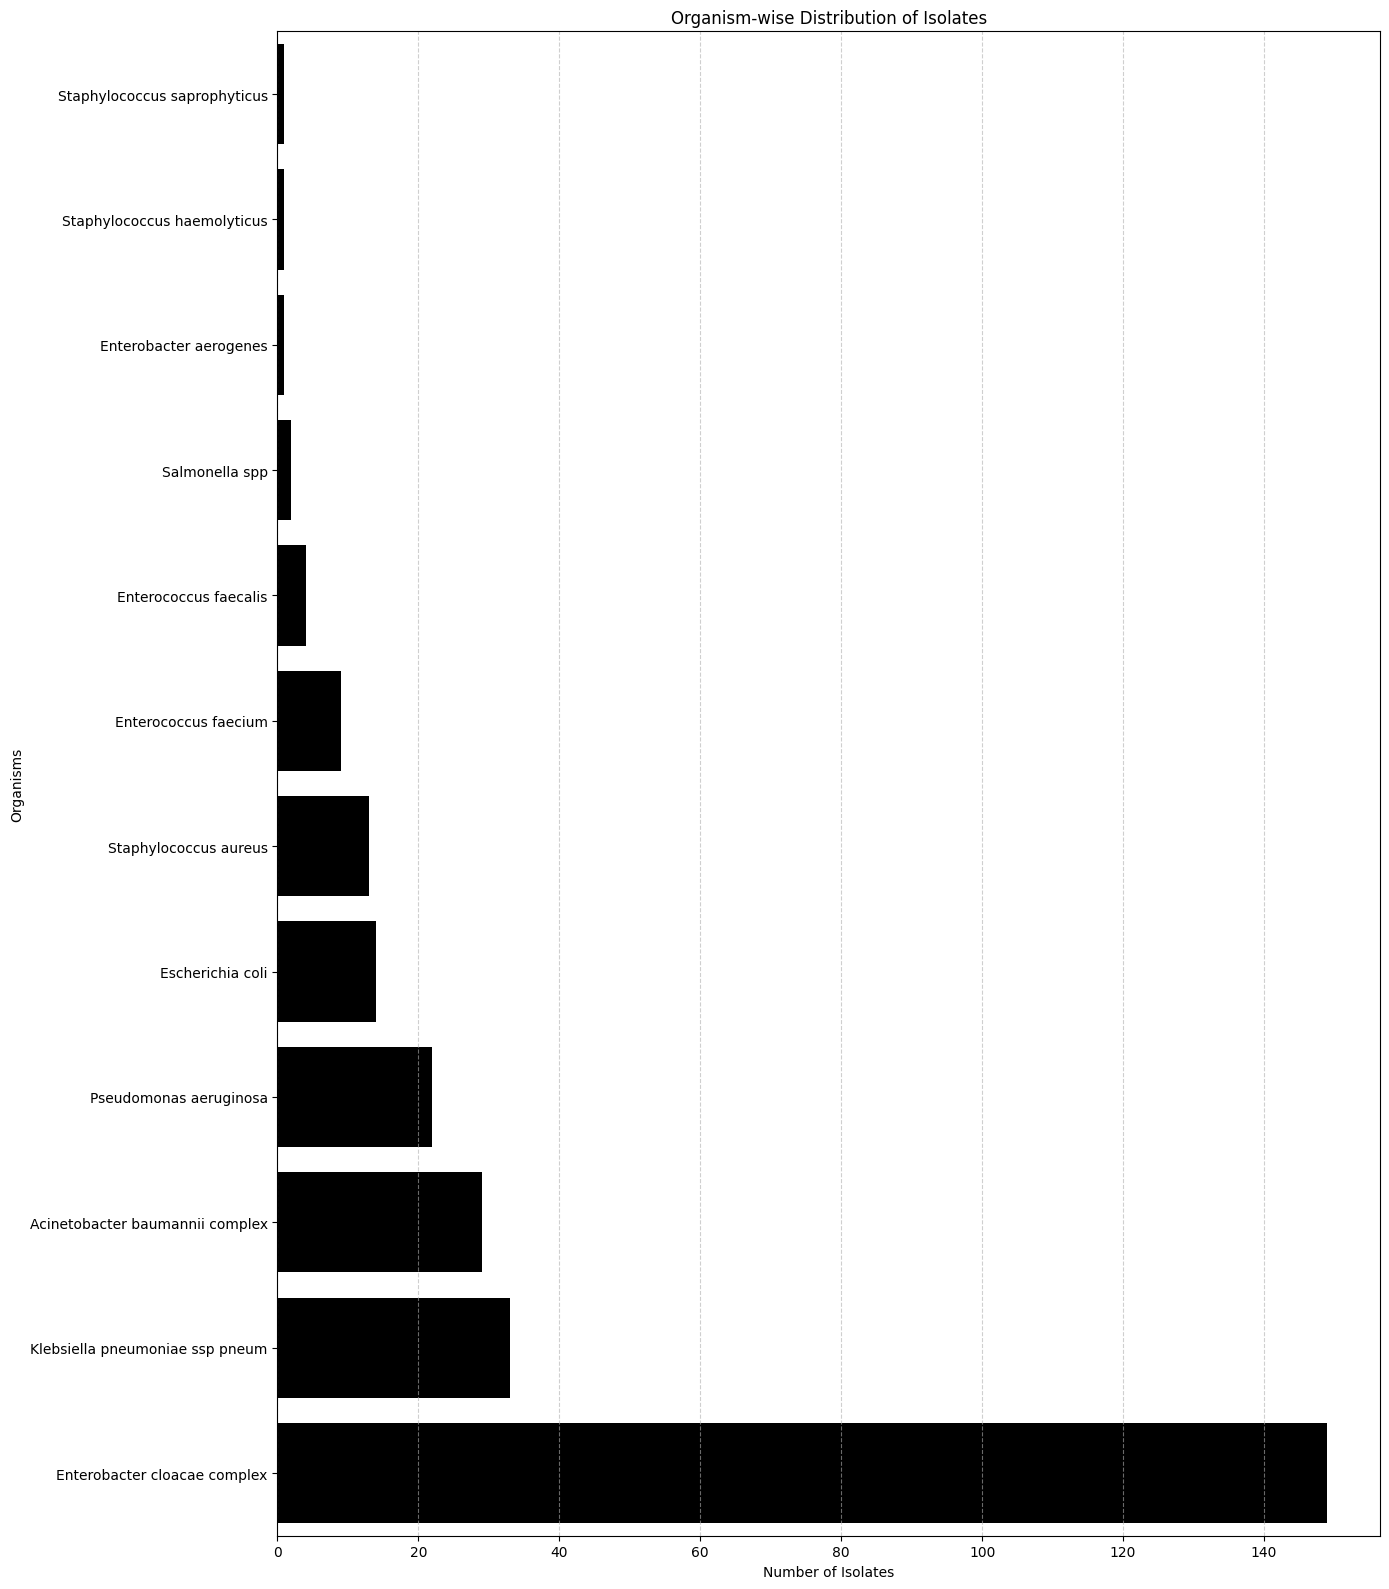

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_excel(r'C:\Users\User\Downloads\AMR_merged_all_samples_ordered.xlsx')

organism_counts = df['Bacteria'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(14,16))
sns.barplot(x=organism_counts.values, y=organism_counts.index, color='black')
plt.title("Organism-wise Distribution of Isolates")
plt.xlabel("Number of Isolates")
plt.ylabel("Organisms")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("C:Documents/Organism-wise_Distribution_of_Isolates.png", dpi=300, bbox_inches='tight')
plt.show()



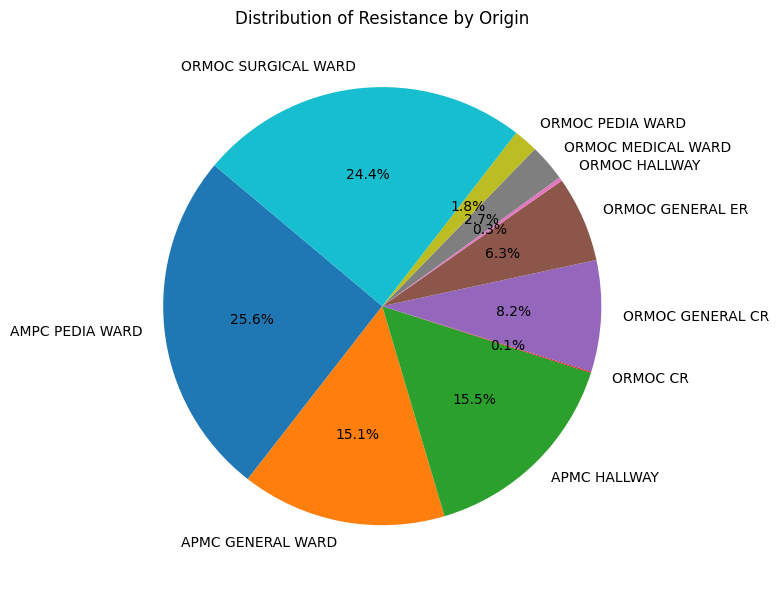

In [111]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel(r'C:\Users\User\Downloads\AMR_merged_all_samples_ordered.xlsx')
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace('\r', '')

resistance_cols = df.columns[4:]  # first 4 columns are Sample_ID, Origin, Bacteria, Unnamed
resistance_data = df[resistance_cols]

resistant_mask = resistance_data == 'R'

resistant_mask['Origin'] = df['Origin']

resistance_by_origin = resistant_mask.groupby('Origin').sum().sum(axis=1)

plt.figure(figsize=(10, 6))
resistance_by_origin.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Resistance by Origin')
plt.ylabel('')
plt.tight_layout()
plt.savefig("C:Documents/Distribution of Resistance by Origin.png", dpi=300, bbox_inches='tight')
plt.show()


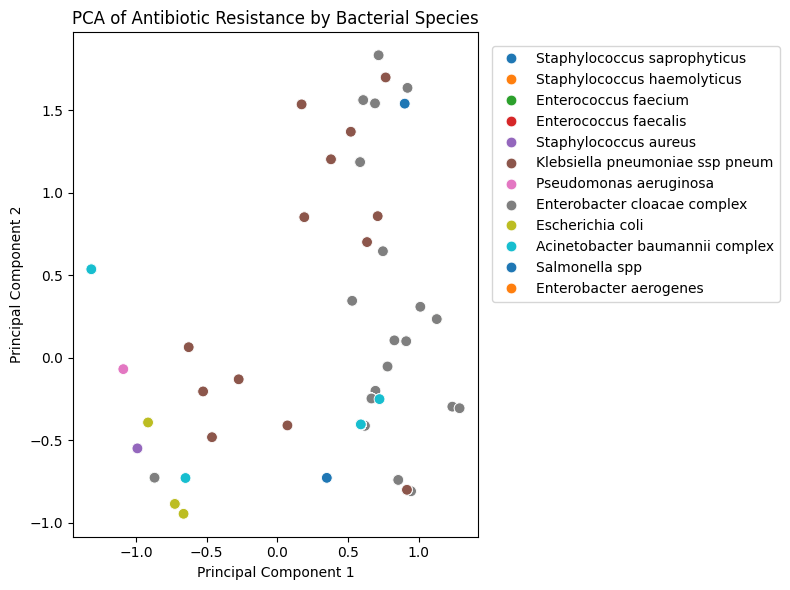

In [115]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

binary_df = (df[resistance_cols] == 'R').astype(int)
X = binary_df.fillna(0)

pca = PCA(n_components=2)
components = pca.fit_transform(X)
df['PC1'], df['PC2'] = components[:, 0], components[:, 1]

plt.figure(figsize=(8, 6))
scatter = sns.scatterplot(data=df, x='PC1', y='PC2', hue='Bacteria', palette='tab10', legend='full', s=60)

plt.legend(bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=1.)
plt.title("PCA of Antibiotic Resistance by Bacterial Species")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.savefig("C:Documents/PCA.png", dpi=300, bbox_inches='tight')

plt.show()

Pearson Correlation

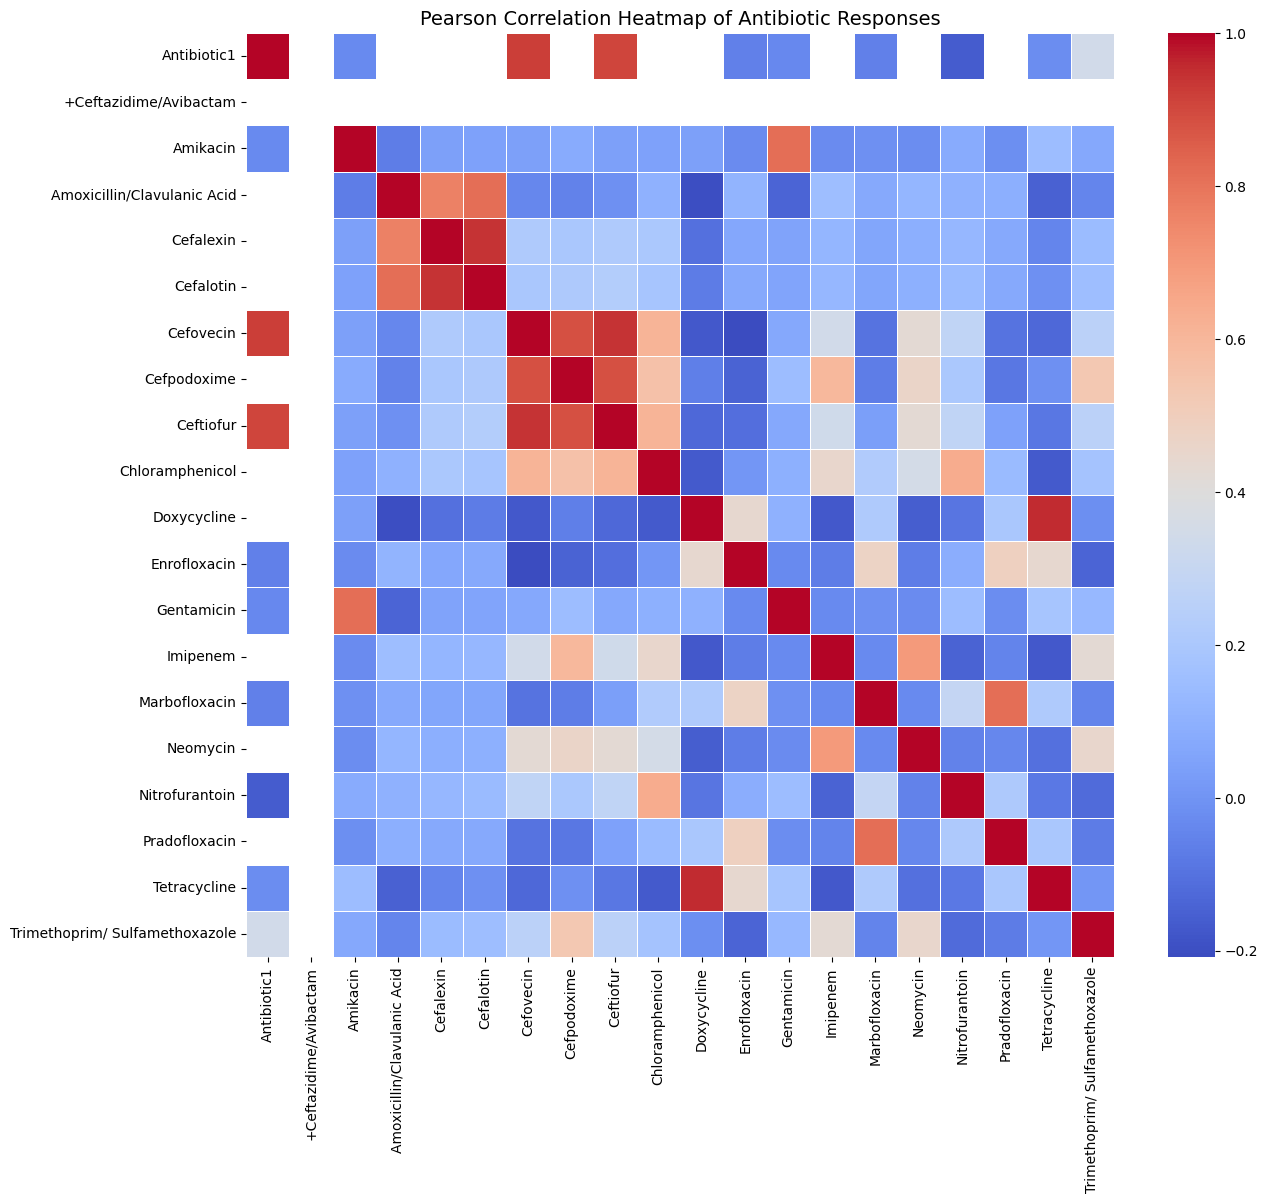


Top 10 Most Correlated Antibiotic Pairs:

Doxycycline   Tetracycline    0.956404
Tetracycline  Doxycycline     0.956404
Cefalotin     Cefalexin       0.940325
Cefalexin     Cefalotin       0.940325
Ceftiofur     Cefovecin       0.939690
Cefovecin     Ceftiofur       0.939690
Antibiotic1   Cefovecin       0.923334
Cefovecin     Antibiotic1     0.923334
Antibiotic1   Ceftiofur       0.907178
Ceftiofur     Antibiotic1     0.907178
dtype: float64


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

meta_cols = ['Sample_ID', 'Origin', 'Bacteria', 'Unnamed: 3']
df = df.drop(columns=[col for col in meta_cols if col in df.columns], errors='ignore')

mapping = {'S': 0, 'I': 0.5, 'R': 1}
df_encoded = df.replace(mapping)

df_encoded = df_encoded.dropna(axis=1, how='all')

corr = df_encoded.corr(method='pearson')

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title("Pearson Correlation Heatmap of Antibiotic Responses", fontsize=14)
plt.show()

corr_unstacked = corr.unstack().sort_values(ascending=False)
top_corr = corr_unstacked[(corr_unstacked < 1)].dropna().head(10)
print("\nTop 10 Most Correlated Antibiotic Pairs:\n")
print(top_corr)



Predicting the Origin of the Isolates

✅ R² Score: 0.5986
📉 RMSE: 2.1748


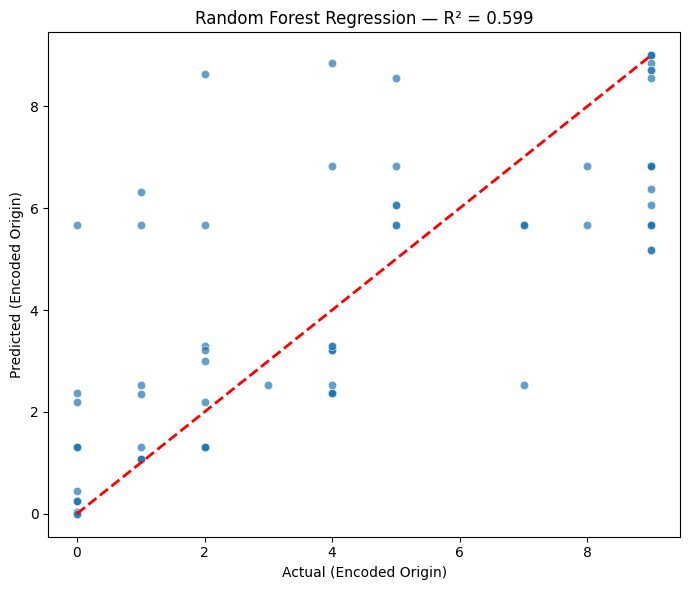

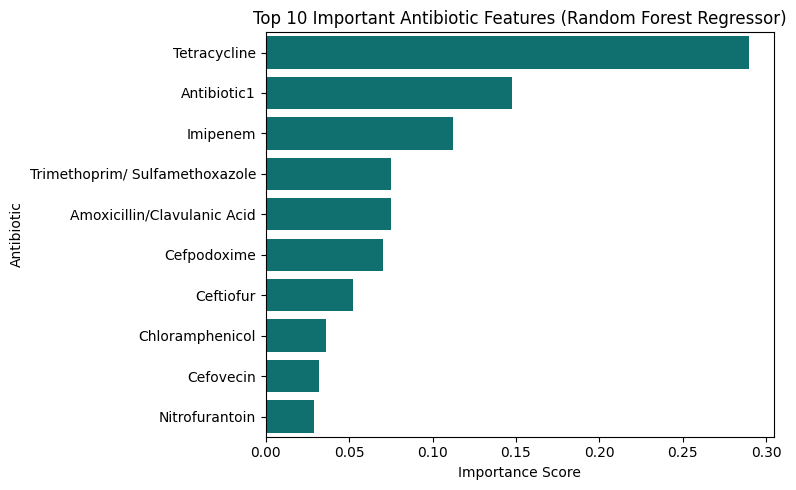

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error

df.columns = df.columns.str.strip()

if 'Origin' not in df.columns:
    raise ValueError("⚠️ The dataset must include a column named 'Origin' representing the ward.")

le = LabelEncoder()
y = le.fit_transform(df['Origin'])

exclude_cols = ['Sample_ID', 'Origin', 'Bacteria']
antibiotic_cols = [c for c in df.columns if c not in exclude_cols]

X = df[antibiotic_cols].copy()

def map_res(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if s in ["R", "RESISTANT"]:
        return 1
    elif s in ["S", "SUSCEPTIBLE", "SENSITIVE", "I", "INTERMEDIATE"]:
        return 0
    else:
        try:
            return float(s)
        except:
            return np.nan

for c in X.columns:
    X[c] = X[c].map(map_res)

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"✅ R² Score: {r2:.4f}")
print(f"📉 RMSE: {rmse:.4f}")

plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title(f"Random Forest Regression — R² = {r2:.3f}")
plt.xlabel("Actual (Encoded Origin)")
plt.ylabel("Predicted (Encoded Origin)")
plt.tight_layout()
plt.show()

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, color='teal')
plt.title("Top 10 Important Antibiotic Features (Random Forest Regressor)")
plt.xlabel("Importance Score")
plt.ylabel("Antibiotic")
plt.tight_layout()
plt.show()


Predicting the Resistance or Susceptibility of the Bacteria to the Antibiotic

🧫 Detected bacteria column: Bacteria
✅ R² Score: 1.0000


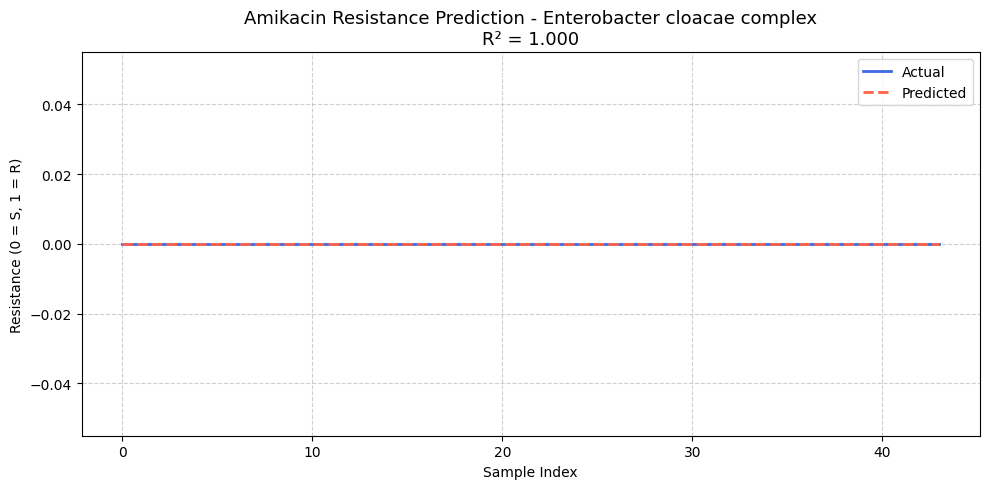

In [117]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r'C:\Users\User\Downloads\AMR_merged_all_samples_ordered.xlsx')

df.columns = df.columns.str.strip()

bacteria_col = None
for col in df.columns:
    if "bacteria" in col.lower():
        bacteria_col = col
        break

if not bacteria_col:
    raise ValueError("❌ Could not find a column containing 'Bacteria'.")

print(f"🧫 Detected bacteria column: {bacteria_col}")

target_bacteria = "Enterobacter cloacae complex"
df = df[df[bacteria_col].astype(str).str.contains(target_bacteria, case=False, na=False)]

target_antibiotic = "Amikacin"
if target_antibiotic not in df.columns:
    raise ValueError(f"⚠️ Column '{target_antibiotic}' not found in dataset.")

def map_res(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if s in ["R", "RESISTANT"]: return 1
    elif s in ["S", "SUSCEPTIBLE", "SENSITIVE", "I", "INTERMEDIATE"]: return 0
    else:
        try:
            return float(s)
        except:
            return np.nan

df[target_antibiotic] = df[target_antibiotic].map(map_res)
df = df.dropna(subset=[target_antibiotic])

exclude_cols = ['Sample_ID', bacteria_col, target_antibiotic]
X = df.drop(columns=[c for c in exclude_cols if c in df.columns])

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(X.median())
y = df[target_antibiotic].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"✅ R² Score: {r2:.4f}")

comparison_df = pd.DataFrame({
    "Actual Resistance": y_test.values,
    "Predicted Resistance": y_pred
}).reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(comparison_df["Actual Resistance"], label="Actual", color="royalblue", linewidth=2)
plt.plot(comparison_df["Predicted Resistance"], label="Predicted", color="tomato", linestyle="--", linewidth=2)
plt.title(f"Amikacin Resistance Prediction - {target_bacteria}\nR² = {r2:.3f}", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Resistance (0 = S, 1 = R)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



🧫 Detected bacteria column: Bacteria
✅ R² Score: 0.9984


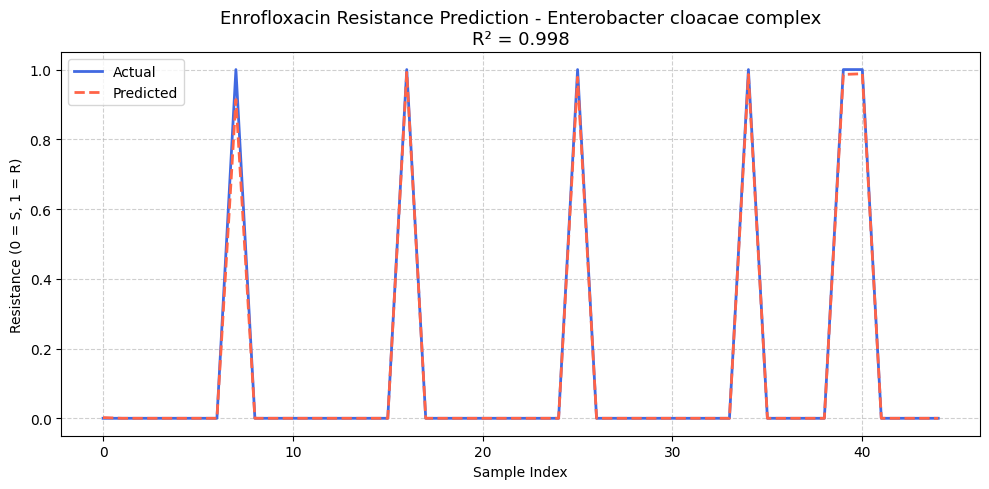

In [118]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r'C:\Users\User\Downloads\AMR_merged_all_samples_ordered.xlsx')

df.columns = df.columns.str.strip()

bacteria_col = None
for col in df.columns:
    if "bacteria" in col.lower():
        bacteria_col = col
        break

if not bacteria_col:
    raise ValueError("❌ Could not find a column containing 'Bacteria'.")

print(f"🧫 Detected bacteria column: {bacteria_col}")

target_bacteria = "Enterobacter cloacae complex"
df = df[df[bacteria_col].astype(str).str.contains(target_bacteria, case=False, na=False)]

target_antibiotic = "Enrofloxacin"
if target_antibiotic not in df.columns:
    raise ValueError(f"⚠️ Column '{target_antibiotic}' not found in dataset.")

def map_res(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if s in ["R", "RESISTANT"]: return 1
    elif s in ["S", "SUSCEPTIBLE", "SENSITIVE", "I", "INTERMEDIATE"]: return 0
    else:
        try:
            return float(s)
        except:
            return np.nan

df[target_antibiotic] = df[target_antibiotic].map(map_res)
df = df.dropna(subset=[target_antibiotic])

exclude_cols = ['Sample_ID', bacteria_col, target_antibiotic]
X = df.drop(columns=[c for c in exclude_cols if c in df.columns])

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(X.median())
y = df[target_antibiotic].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"✅ R² Score: {r2:.4f}")

comparison_df = pd.DataFrame({
    "Actual Resistance": y_test.values,
    "Predicted Resistance": y_pred
}).reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(comparison_df["Actual Resistance"], label="Actual", color="royalblue", linewidth=2)
plt.plot(comparison_df["Predicted Resistance"], label="Predicted", color="tomato", linestyle="--", linewidth=2)
plt.title(f"Enrofloxacin Resistance Prediction - {target_bacteria}\nR² = {r2:.3f}", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Resistance (0 = S, 1 = R)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



🧫 Detected bacteria column: Bacteria
✅ R² Score: 0.4017


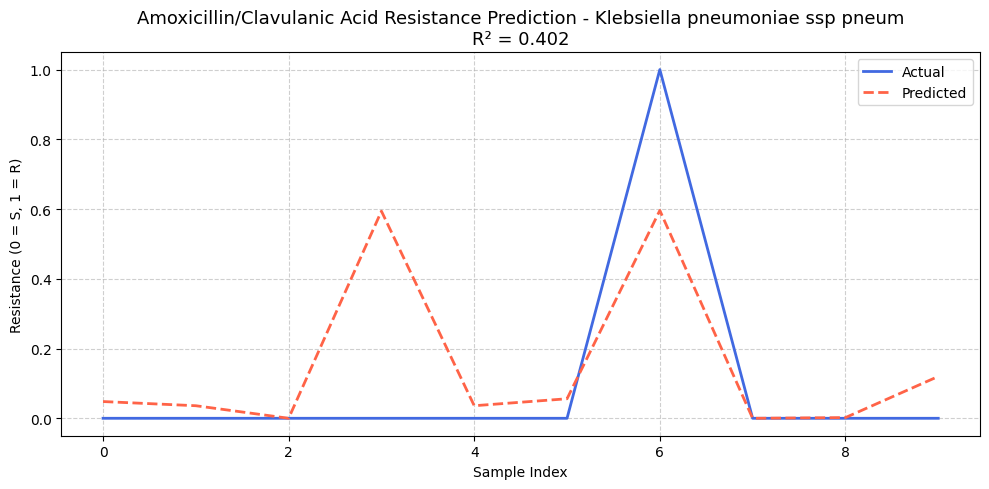

In [119]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r'C:\Users\User\Downloads\AMR_merged_all_samples_ordered.xlsx')

df.columns = df.columns.str.strip()

bacteria_col = None
for col in df.columns:
    if "bacteria" in col.lower():
        bacteria_col = col
        break

if not bacteria_col:
    raise ValueError("❌ Could not find a column containing 'Bacteria'.")

print(f"🧫 Detected bacteria column: {bacteria_col}")

target_bacteria = "Klebsiella pneumoniae ssp pneum"
df = df[df[bacteria_col].astype(str).str.contains(target_bacteria, case=False, na=False)]

target_antibiotic = "Amoxicillin/Clavulanic Acid"
if target_antibiotic not in df.columns:
    raise ValueError(f"⚠️ Column '{target_antibiotic}' not found in dataset.")

def map_res(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if s in ["R", "RESISTANT"]: return 1
    elif s in ["S", "SUSCEPTIBLE", "SENSITIVE", "I", "INTERMEDIATE"]: return 0
    else:
        try:
            return float(s)
        except:
            return np.nan

df[target_antibiotic] = df[target_antibiotic].map(map_res)
df = df.dropna(subset=[target_antibiotic])

exclude_cols = ['Sample_ID', bacteria_col, target_antibiotic]
X = df.drop(columns=[c for c in exclude_cols if c in df.columns])

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(X.median())
y = df[target_antibiotic].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"✅ R² Score: {r2:.4f}")

comparison_df = pd.DataFrame({
    "Actual Resistance": y_test.values,
    "Predicted Resistance": y_pred
}).reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(comparison_df["Actual Resistance"], label="Actual", color="royalblue", linewidth=2)
plt.plot(comparison_df["Predicted Resistance"], label="Predicted", color="tomato", linestyle="--", linewidth=2)
plt.title(f"Amoxicillin/Clavulanic Acid Resistance Prediction - {target_bacteria}\nR² = {r2:.3f}", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Resistance (0 = S, 1 = R)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



🧫 Detected bacteria column: Bacteria
✅ R² Score: 0.8675


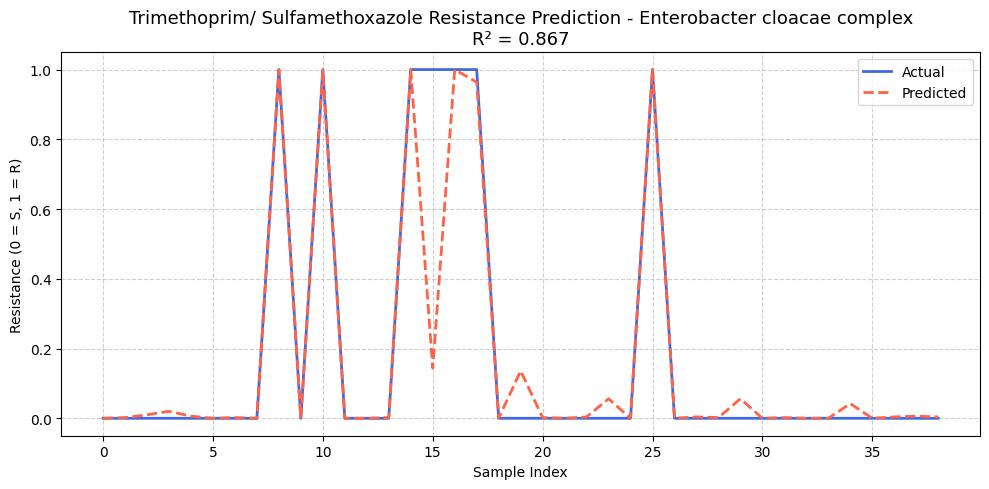

In [120]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r'C:\Users\User\Downloads\AMR_merged_all_samples_ordered.xlsx')

df.columns = df.columns.str.strip()

bacteria_col = None
for col in df.columns:
    if "bacteria" in col.lower():
        bacteria_col = col
        break

if not bacteria_col:
    raise ValueError("❌ Could not find a column containing 'Bacteria'.")

print(f"🧫 Detected bacteria column: {bacteria_col}")

target_bacteria = "Enterobacter cloacae complex"
df = df[df[bacteria_col].astype(str).str.contains(target_bacteria, case=False, na=False)]

target_antibiotic = "Trimethoprim/ Sulfamethoxazole"
if target_antibiotic not in df.columns:
    raise ValueError(f"⚠️ Column '{target_antibiotic}' not found in dataset.")

def map_res(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if s in ["R", "RESISTANT"]: return 1
    elif s in ["S", "SUSCEPTIBLE", "SENSITIVE", "I", "INTERMEDIATE"]: return 0
    else:
        try:
            return float(s)
        except:
            return np.nan

df[target_antibiotic] = df[target_antibiotic].map(map_res)
df = df.dropna(subset=[target_antibiotic])

exclude_cols = ['Sample_ID', bacteria_col, target_antibiotic]
X = df.drop(columns=[c for c in exclude_cols if c in df.columns])

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(X.median())
y = df[target_antibiotic].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"✅ R² Score: {r2:.4f}")

comparison_df = pd.DataFrame({
    "Actual Resistance": y_test.values,
    "Predicted Resistance": y_pred
}).reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(comparison_df["Actual Resistance"], label="Actual", color="royalblue", linewidth=2)
plt.plot(comparison_df["Predicted Resistance"], label="Predicted", color="tomato", linestyle="--", linewidth=2)
plt.title(f"Trimethoprim/ Sulfamethoxazole Resistance Prediction - {target_bacteria}\nR² = {r2:.3f}", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Resistance (0 = S, 1 = R)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



In [124]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel(r'C:\Users\User\Downloads\AMR_merged_all_samples_ordered.xlsx')

df.columns = df.columns.str.strip()

bacteria_col = None
for col in df.columns:
    if "bacteria" in col.lower():
        bacteria_col = col
        break

if not bacteria_col:
    raise ValueError("❌ Could not find a column containing 'Bacteria'.")

print(f"🧫 Detected bacteria column: {bacteria_col}")

target_bacteria = "Acinetobacter baumannii complex"
df = df[df[bacteria_col].astype(str).str.contains(target_bacteria, case=False, na=False)]

target_antibiotic = "Trimethoprim/ Sulfamethoxazole"
if target_antibiotic not in df.columns:
    raise ValueError(f"⚠️ Column '{target_antibiotic}' not found in dataset.")

def map_res(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if s in ["R", "RESISTANT"]: return 1
    elif s in ["S", "SUSCEPTIBLE", "SENSITIVE", "I", "INTERMEDIATE"]: return 0
    else:
        try:
            return float(s)
        except:
            return np.nan

df[target_antibiotic] = df[target_antibiotic].map(map_res)
df = df.dropna(subset=[target_antibiotic])

exclude_cols = ['Sample_ID', bacteria_col, target_antibiotic]
X = df.drop(columns=[c for c in exclude_cols if c in df.columns])

for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(X.median())
y = df[target_antibiotic].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf_reg = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)

y_pred = rf_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)

print(f"✅ R² Score: {r2:.4f}")

comparison_df = pd.DataFrame({
    "Actual Resistance": y_test.values,
    "Predicted Resistance": y_pred
}).reset_index(drop=True)

plt.figure(figsize=(10,5))
plt.plot(comparison_df["Actual Resistance"], label="Actual", color="royalblue", linewidth=2)
plt.plot(comparison_df["Predicted Resistance"], label="Predicted", color="tomato", linestyle="--", linewidth=2)
plt.title(f"Trimethoprim/ Sulfamethoxazole Resistance Prediction - {target_bacteria}\nR² = {r2:.3f}", fontsize=13)
plt.xlabel("Sample Index")
plt.ylabel("Resistance (0 = S, 1 = R)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



🧫 Detected bacteria column: Bacteria


ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.